## March Machine Learning Mania 2026
________________________________________
## Project Overview:

This project focuses on the March Machine Learning Mania 2026 challenge, where the objective is to predict the outcome of NCAA college basketball tournament games. Predicting these outcomes is highly challenging due to the "madness" of the tournament—where upsets are frequent and historical performance doesn't always guarantee future success.

## Methodology & Workflow:
___________________________

## Data Engineering & Aggregation: 

The core of this project involved merging multiple datasets, including regular season statistics, tournament results, and team information.

I created a comprehensive "Master Dataset" by aggregating seasonal performance metrics (like wins, losses, and scoring margins) to provide the models with a holistic view of each team's strength.

## Preprocessing & Feature Scaling:

Handled data inconsistencies and ensured all features were numerical.

Since different features had different scales (e.g., total points vs. win percentage), I applied StandardScaler to ensure that no single feature dominates the model's learning process.

## Advanced Predictive Modeling:

I implemented a variety of machine learning architectures to compare their effectiveness:

Baseline Model: Logistic Regression to establish a starting point.

Tree-Based Models: Decision Tree to capture non-linear relationships.

Ensemble Methods: Random Forest and XGBoost (Extreme Gradient Boosting) to reduce variance and bias, leading to more robust predictions.

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

## AGGREGATE ALL CSV FILES IN MASTER CSV

In [3]:
def create_final_master():
    m_teams = pd.read_csv('MTeams.csv')
    w_teams = pd.read_csv('WTeams.csv')
    m_seeds = pd.read_csv('MNCAATourneySeeds.csv')
    w_seeds = pd.read_csv('WNCAATourneySeeds.csv')
    m_reg = pd.read_csv('MRegularSeasonCompactResults.csv')
    w_reg = pd.read_csv('WRegularSeasonCompactResults.csv')
    m_tourney = pd.read_csv('MNCAATourneyCompactResults.csv')
    w_tourney = pd.read_csv('WNCAATourneyCompactResults.csv')

    def process_gender(teams, seeds, reg, tourney, gender_label):
        seeds['SeedNumber'] = seeds['Seed'].apply(lambda x: int(''.join(filter(str.isdigit, x))))
        
       
        w_stats = reg.groupby(['Season', 'WTeamID']).agg(AvgScore=('WScore', 'mean'), Wins=('WTeamID', 'count')).reset_index().rename(columns={'WTeamID': 'TeamID'})
        l_stats = reg.groupby(['Season', 'LTeamID']).agg(AvgScore=('LScore', 'mean'), Losses=('LTeamID', 'count')).reset_index().rename(columns={'LTeamID': 'TeamID'})
        
        stats = pd.merge(w_stats, l_stats, on=['Season', 'TeamID'], how='outer').fillna(0)
        stats['SeasonWinRatio'] = stats['Wins'] / (stats['Wins'] + stats['Losses'])
        stats['SeasonAvgScore'] = (stats['AvgScore_x'] + stats['AvgScore_y']) / 2
        
    
        profile = pd.merge(stats[['Season', 'TeamID', 'SeasonAvgScore', 'SeasonWinRatio']], teams[['TeamID', 'TeamName']], on='TeamID')
        profile = pd.merge(profile, seeds[['Season', 'TeamID', 'SeedNumber']], on=['Season', 'TeamID'], how='left')

    
        master = tourney[['Season', 'WTeamID', 'LTeamID', 'WScore', 'LScore']].copy()
        
        
        half1 = master.sample(frac=0.5, random_state=42)
        half1 = half1.rename(columns={'WTeamID': 'T1_ID', 'LTeamID': 'T2_ID'})
        half1['Target'] = 1

        half2 = master.drop(half1.index)
        half2 = half2.rename(columns={'LTeamID': 'T1_ID', 'WTeamID': 'T2_ID'})
        half2['Target'] = 0
        
        combined_tourney = pd.concat([half1, half2])


        final = pd.merge(combined_tourney, profile, left_on=['Season', 'T1_ID'], right_on=['Season', 'TeamID'], how='left')
        final = final.rename(columns={col: col+'_T1' for col in profile.columns if col != 'Season'})
        
    
        final = pd.merge(final, profile, left_on=['Season', 'T2_ID'], right_on=['Season', 'TeamID'], how='left')
        final = final.rename(columns={col: col+'_T2' for col in profile.columns if col != 'Season'})
        
        final['Gender'] = gender_label
        return final.drop(columns=['TeamID_T1', 'TeamID_T2'])

    m_final = process_gender(m_teams, m_seeds, m_reg, m_tourney, 'Men')
    w_final = process_gender(w_teams, w_seeds, w_reg, w_tourney, 'Women')
    
    master_csv = pd.concat([m_final, w_final]).reset_index(drop=True)
    master_csv.to_csv('Master_Final_All_Columns.csv', index=False)
    return master_csv

df_master = create_final_master()
print("Master CSV Saved")
print(df_master.head())

Master CSV Saved
   Season  T1_ID  T2_ID  WScore  LScore  Target  SeasonAvgScore_T1  \
0    1993   1153   1308      92      55       1          68.937500   
1    2024   1181   1241      93      55       1          78.354167   
2    1993   1242   1143      93      76       1          76.068182   
3    1991   1326   1210      65      61       1          76.653333   
4    1997   1257   1307      64      63       1          70.611413   

   SeasonWinRatio_T1 TeamName_T1  SeedNumber_T1  SeasonAvgScore_T2  \
0           0.857143  Cincinnati            2.0          73.831169   
1           0.750000        Duke            4.0          75.933333   
2           0.785714      Kansas            2.0          77.253289   
3           0.892857     Ohio St            1.0          81.739583   
4           0.741935  Louisville            6.0          71.077640   

   SeasonWinRatio_T2    TeamName_T2  SeedNumber_T2 Gender  
0           0.758621  New Mexico St            7.0    Men  
1           0.909091 

## LOADING NEW DATAFRAME

In [4]:
df = pd.read_csv("Master_Final_All_Columns.csv")

In [5]:
df.head() #checking data is loaded correctly or not

,Season,T1_ID,T2_ID,WScore,LScore,Target,SeasonAvgScore_T1,SeasonWinRatio_T1,TeamName_T1,SeedNumber_T1,SeasonAvgScore_T2,SeasonWinRatio_T2,TeamName_T2,SeedNumber_T2,Gender
0,1993,1153,1308,92,55,1,68.937500,0.857143,Cincinnati,2.0,73.831169,0.758621,New Mexico St,7.0,Men
1,2024,1181,1241,93,55,1,78.354167,0.750000,Duke,4.0,75.933333,0.909091,James Madison,12.0,Men
2,1993,1242,1143,93,76,1,76.068182,0.785714,Kansas,2.0,77.253289,0.703704,California,6.0,Men
3,1991,1326,1210,65,61,1,76.653333,0.892857,Ohio St,1.0,81.739583,0.571429,Georgia Tech,8.0,Men
4,1997,1257,1307,64,63,1,70.611413,0.741935,Louisville,6.0,71.077640,0.766667,New Mexico,3.0,Men


In [6]:
df["Target"].value_counts() #Checking data is imbalanced or balanced

Target
0    2152
1    2150
Name: count, dtype: int64

In [7]:
print("Numbers of null values in each columns /n" , df.isnull().sum()) #Zero Null Values

Numbers of null values in each columns /n Season               0
T1_ID                0
T2_ID                0
WScore               0
LScore               0
Target               0
SeasonAvgScore_T1    0
SeasonWinRatio_T1    0
TeamName_T1          0
SeedNumber_T1        0
SeasonAvgScore_T2    0
SeasonWinRatio_T2    0
TeamName_T2          0
SeedNumber_T2        0
Gender               0
dtype: int64


In [8]:
print("Duplicate rows in datase = ",df.duplicated().sum()) #No Duplicates

Duplicate rows in datase =  0


In [9]:
df.dtypes #Checking datatypes of each columns

Season                 int64
T1_ID                  int64
T2_ID                  int64
WScore                 int64
LScore                 int64
Target                 int64
SeasonAvgScore_T1    float64
SeasonWinRatio_T1    float64
TeamName_T1           object
SeedNumber_T1        float64
SeasonAvgScore_T2    float64
SeasonWinRatio_T2    float64
TeamName_T2           object
SeedNumber_T2        float64
Gender                object
dtype: object

In [10]:
df.head() #For matching all dataypes

,Season,T1_ID,T2_ID,WScore,LScore,Target,SeasonAvgScore_T1,SeasonWinRatio_T1,TeamName_T1,SeedNumber_T1,SeasonAvgScore_T2,SeasonWinRatio_T2,TeamName_T2,SeedNumber_T2,Gender
0,1993,1153,1308,92,55,1,68.937500,0.857143,Cincinnati,2.0,73.831169,0.758621,New Mexico St,7.0,Men
1,2024,1181,1241,93,55,1,78.354167,0.750000,Duke,4.0,75.933333,0.909091,James Madison,12.0,Men
2,1993,1242,1143,93,76,1,76.068182,0.785714,Kansas,2.0,77.253289,0.703704,California,6.0,Men
3,1991,1326,1210,65,61,1,76.653333,0.892857,Ohio St,1.0,81.739583,0.571429,Georgia Tech,8.0,Men
4,1997,1257,1307,64,63,1,70.611413,0.741935,Louisville,6.0,71.077640,0.766667,New Mexico,3.0,Men


## Checking Outliers (Visualization)

In [11]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns.to_list()

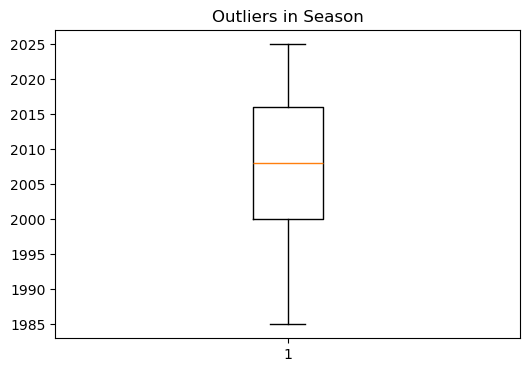

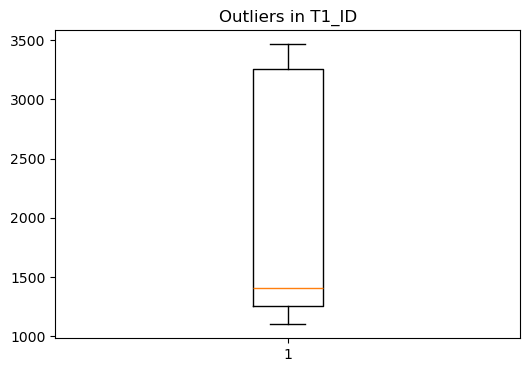

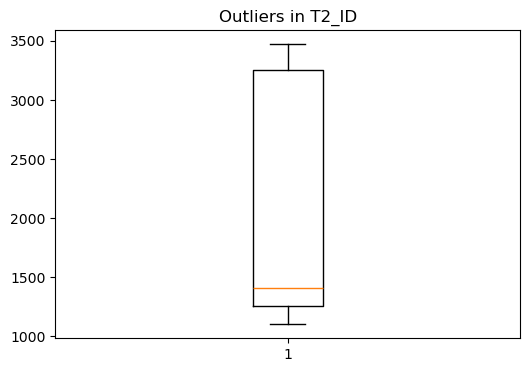

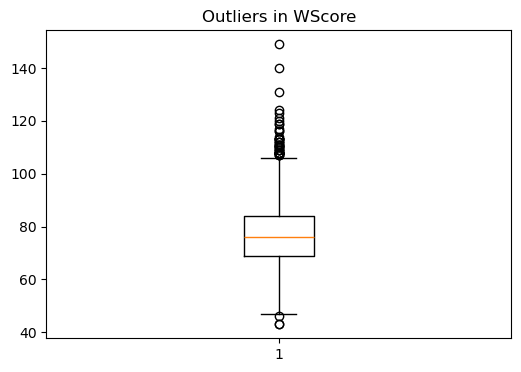

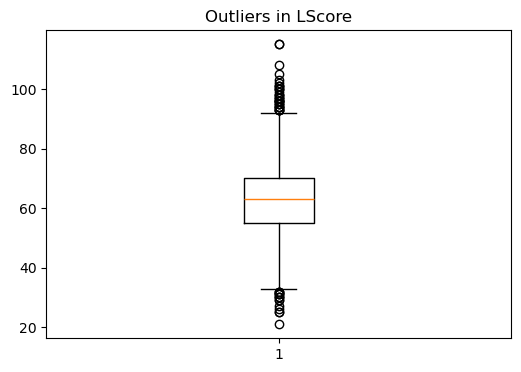

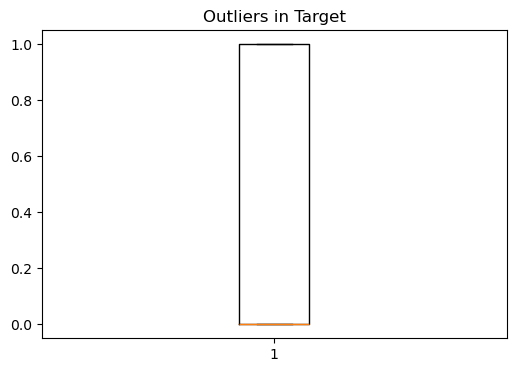

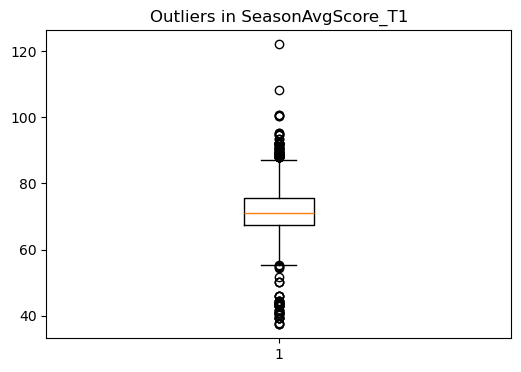

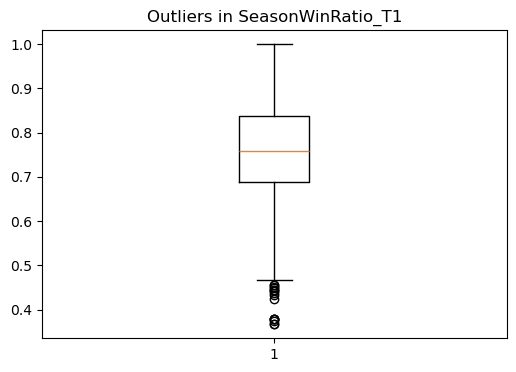

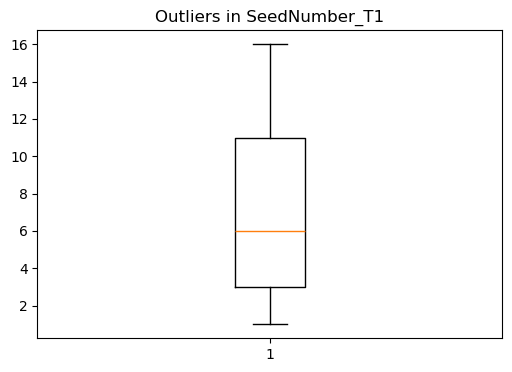

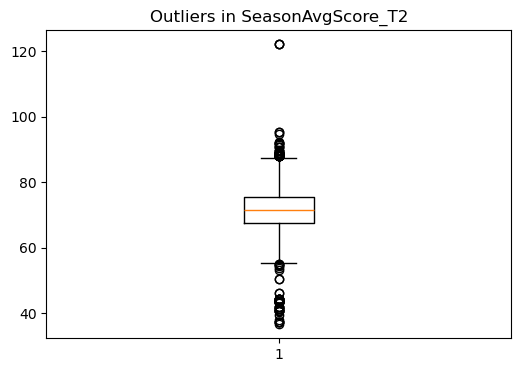

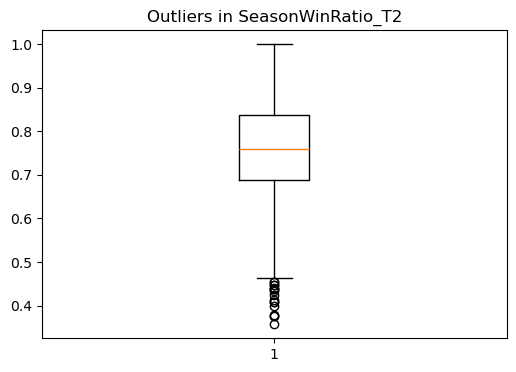

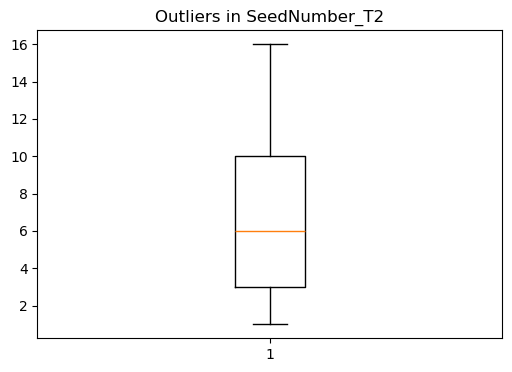

In [12]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    plt.boxplot(df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

## Checking Outliers (Numerical)

In [13]:
for cols in num_cols:
    Q1 = df[cols].quantile(0.25)
    Q3 = df[cols].quantile(0.75)
    IQR = Q3-Q1

    lower_bound = Q1-1.5*IQR
    upper_bound = Q3+1.5*IQR

    Outliers = ( df[cols]<lower_bound ) | (df[cols]>upper_bound)

    print(f"{cols:<17} | Outliers = {Outliers.sum()}")

Season            | Outliers = 0
T1_ID             | Outliers = 0
T2_ID             | Outliers = 0
WScore            | Outliers = 49
LScore            | Outliers = 51
Target            | Outliers = 0
SeasonAvgScore_T1 | Outliers = 123
SeasonWinRatio_T1 | Outliers = 17
SeedNumber_T1     | Outliers = 0
SeasonAvgScore_T2 | Outliers = 94
SeasonWinRatio_T2 | Outliers = 17
SeedNumber_T2     | Outliers = 0


## VISUALIZATION ( For Some Insights from Data )
_____________________________________________________

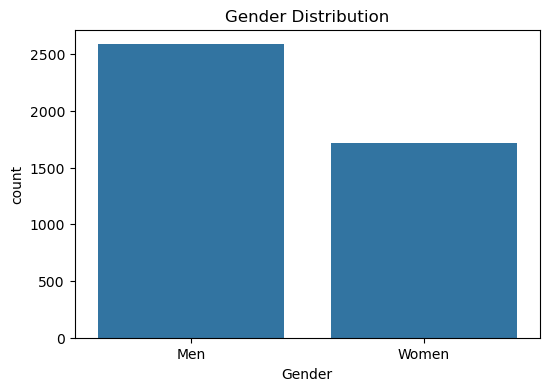

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x="Gender",data=df)
plt.title("Gender Distribution")
plt.show()

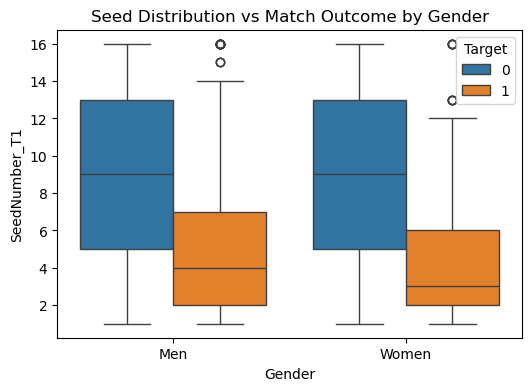

In [15]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Gender', y='SeedNumber_T1', hue='Target')
plt.title("Seed Distribution vs Match Outcome by Gender")
plt.show()

## 1. Gender Data Distribution
___________________________________
- Imbalanced History: The dataset contains significantly more matches for the Men’s Tournament compared to the Women’s Tournament.

- Data Depth: This difference exists because the historical data for Men’s matches starts from 1985, whereas the Women’s data collection began later in 1998.

- Model Training: Since there are more Men's examples (~2500+) than Women's (~1700+), the model will have a deeper understanding of Men’s historical basketball trends.

## 2. Seed Impact on Tournament Outcomes
___________________________________________
- Winning Correlation: There is a very strong correlation between a team's Seed Number and its probability of winning. Teams with lower seed numbers (Rank 1 to 4) are significantly more likely to be in the "Winner" category (Target 1).

- Gender Comparison in Predictability: * Women’s Tournament: The winning boxes (Target 1) for women are much tighter and lower on the seed scale. This suggests that the Women’s tournament is highly predictable, where top-ranked teams almost always win.

- Men’s Tournament: There is a wider distribution of winners across higher seeds (Rank 8 to 12). This indicates that "Upsets" are much more common in Men's basketball compared to Women's.

- The "Upset" Threshold: Teams seeded above 12 rarely enter the winning category in either gender, confirming that extreme upsets are rare statistical outliers in the NCAA tournament.

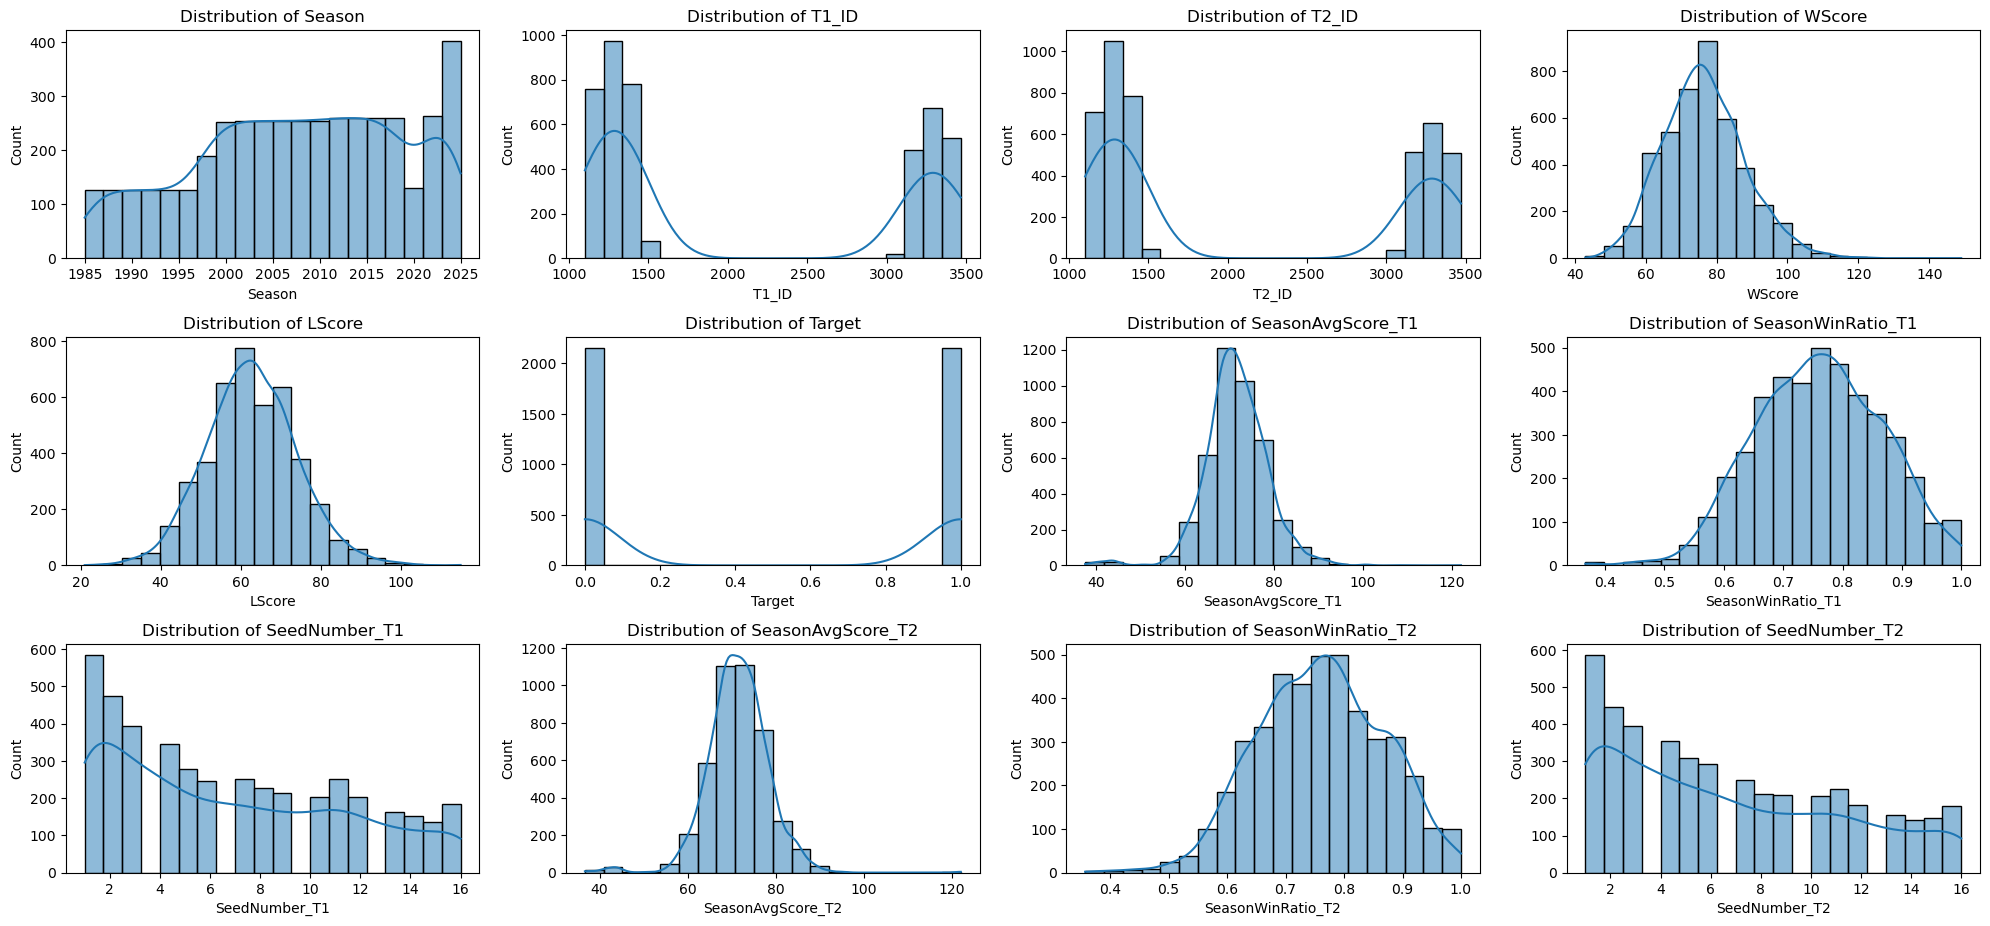

In [16]:
plt.figure(figsize = (20,12))

for i,col in enumerate(num_cols, 1):
    plt.subplot(4,4,i)
    sns.histplot(x=col, kde=True, bins=20, data=df)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA) & Key Insights
_____________________________________________________________

## 1. Historical Data Distribution: The Tale of Two Eras
The Veteran (Men’s Data): Our dataset has a much higher volume of Men’s matches because the records date back to 1985.

- The Rising Star (Women’s Data): Women’s tournament data is more recent, with consistent tracking starting from 1998.

- Project Impact: This imbalance means our model has a "deeper memory" of Men’s basketball trends, while the Women’s predictions rely on a more modern but smaller sample size.
  
## 2. The Power of Seeding: Order vs. Chaos
The Rule of the Elite: Across both genders, teams with Seeds 1 to 4 have a massive winning advantage.

- Predictability in Women’s League: In the Women’s tournament, rank is almost "Law." Lower-ranked teams (high seeds) rarely pull off a victory, making the games very stable and predictable.

- T- he "Upset" Factor in Men’s League: Men’s basketball is the "Land of Chaos." Even teams seeded 10th or 12th frequently beat top-tier giants, which is why predicting Men's "Cinderella stories" is the toughest part of this project.

## 3. Performance DNA: What Makes a Winner?
The Offensive Sweet Spot: Most competitive teams average between 60 to 80 points per game. Teams scoring outside this bell curve are rare "Outliers" (either extreme defensive or high-octane offensive teams).

- The 70% Win Threshold: Teams that qualify for the tournament usually enter with a regular-season Win Ratio of 0.70 (70%) or higher. A team with a win ratio below 0.60 is statistically much more likely to lose in the first round.

- Dataset Integrity: Our Target variable (Wins vs. Losses) is perfectly balanced at a 50/50 split. This ensures our machine learning model doesn't develop a "bias" and learns to recognize both winning and losing patterns equally.

## Summary of Findings
- Our EDA proves that while raw stats like Average Score are important, the Seed Number and Gender are the ultimate game-changers. By understanding that Women's games respect the 'Rank' while Men's games invite 'Chaos,' we can build a more intelligent prediction model that adapts to the specific nature of each tournament.

In [17]:
df.head()

,Season,T1_ID,T2_ID,WScore,LScore,Target,SeasonAvgScore_T1,SeasonWinRatio_T1,TeamName_T1,SeedNumber_T1,SeasonAvgScore_T2,SeasonWinRatio_T2,TeamName_T2,SeedNumber_T2,Gender
0,1993,1153,1308,92,55,1,68.937500,0.857143,Cincinnati,2.0,73.831169,0.758621,New Mexico St,7.0,Men
1,2024,1181,1241,93,55,1,78.354167,0.750000,Duke,4.0,75.933333,0.909091,James Madison,12.0,Men
2,1993,1242,1143,93,76,1,76.068182,0.785714,Kansas,2.0,77.253289,0.703704,California,6.0,Men
3,1991,1326,1210,65,61,1,76.653333,0.892857,Ohio St,1.0,81.739583,0.571429,Georgia Tech,8.0,Men
4,1997,1257,1307,64,63,1,70.611413,0.741935,Louisville,6.0,71.077640,0.766667,New Mexico,3.0,Men


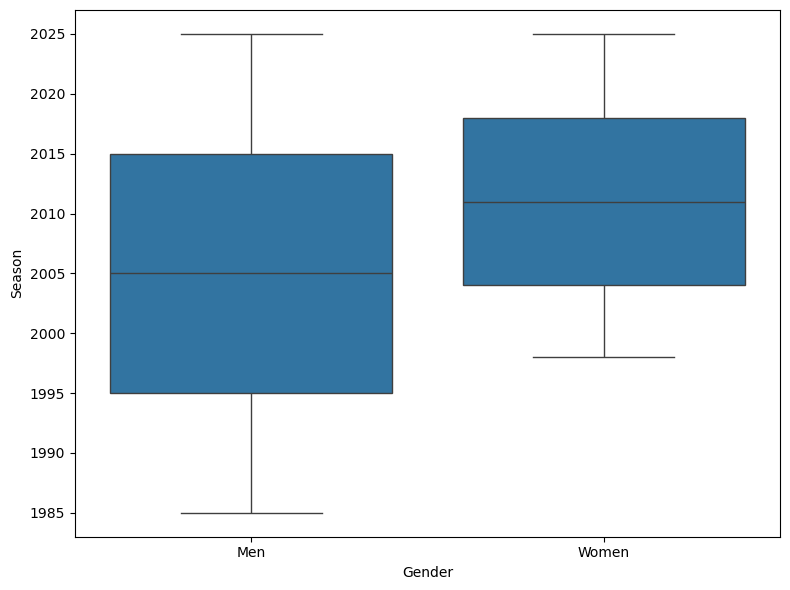

In [18]:
plt.figure (figsize = (8,6))
sns.boxplot(x="Gender",y="Season",data=df)
plt.tight_layout()
plt.show()

## INSIGHTS :- 

## Timeline Coverage: 
- The Men's dataset has a broader historical range starting from 1985, while the Women's dataset begins in the late 1990s.

## Data Concentration:
- The Women's data is more concentrated in recent decades, as shown by the higher position of its median line compared to the Men's data.

## Final Year Alignment: 
- Both datasets are fully updated and conclude at the year 2025, showing consistent data collection for the most recent seasons.

## CO-RELATION CHECKING FOR FEATURE SELECTION
________________________________________________

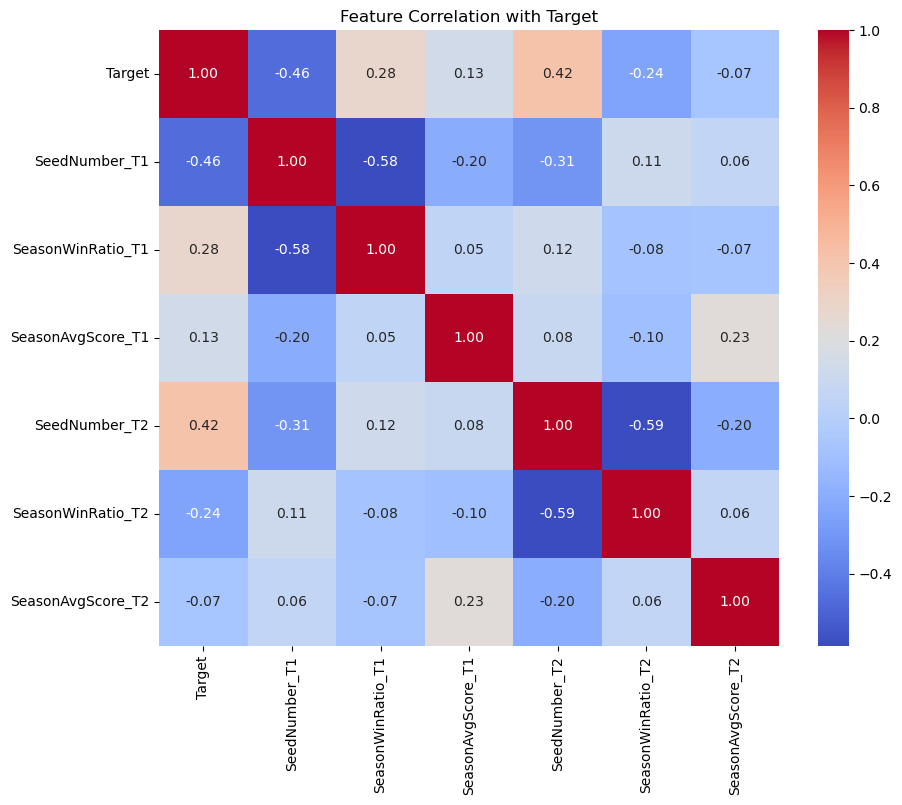

Correlation with Target (Winning Probability):
Target               1.000000
SeedNumber_T2        0.417081
SeasonWinRatio_T1    0.281117
SeasonAvgScore_T1    0.132488
SeasonAvgScore_T2   -0.071329
SeasonWinRatio_T2   -0.239726
SeedNumber_T1       -0.463932
Name: Target, dtype: float64


In [19]:
numeric_cols = ['Target', 'SeedNumber_T1', 'SeasonWinRatio_T1', 'SeasonAvgScore_T1', 
                'SeedNumber_T2', 'SeasonWinRatio_T2', 'SeasonAvgScore_T2']

corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Target')
plt.show()

print("Correlation with Target (Winning Probability):")
print(corr_matrix['Target'].sort_values(ascending=False))

## Heatmap Insights:-

- Rank is King: The Seed Number has the highest impact on the game outcome. Lower seeds consistently dominate the winning side.

- Winning Habit Matters: Teams with a higher Regular Season Win Ratio show a clear positive correlation with winning tournament matches.

- Predictor Strength: The correlation between Seed and Win Ratio is stronger than Average Score, meaning a team's ranking and consistency are better indicators of success than just how many points they score.

- Data Symmetry: Since the correlation values for Team 1 and Team 2 are almost identical but opposite (inverse), our dataset is perfectly balanced for a machine learning model.

## Feature Engineering

In [20]:
df["Seed_Diff"] = df["SeedNumber_T1"] - df["SeedNumber_T2"]
df["WinRatio_Diff"] = df["SeasonWinRatio_T1"] - df["SeasonWinRatio_T2"]
df["AvgScore_Diff"] = df["SeasonAvgScore_T1"] - df["SeasonAvgScore_T2"]
df["WinRatio_Seed_Interaction"] = df["WinRatio_Diff"] * df["Seed_Diff"]

## Encoding (Categorical → Numerical)

In [21]:
categorical_cols = df.select_dtypes(include=["object"]).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

## Define X and y

In [22]:
X = df.drop("Target", axis=1)
y = df["Target"]

## Train Test Split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression (Scaled)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_log)*100)
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 70.73170731707317
              precision    recall  f1-score   support

           0       0.70      0.72      0.71       431
           1       0.71      0.70      0.70       430

    accuracy                           0.71       861
   macro avg       0.71      0.71      0.71       861
weighted avg       0.71      0.71      0.71       861



## Decision Tree

In [25]:
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=4,
    random_state=42
)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt)*100)
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 71.54471544715447
              precision    recall  f1-score   support

           0       0.71      0.74      0.72       431
           1       0.73      0.69      0.71       430

    accuracy                           0.72       861
   macro avg       0.72      0.72      0.72       861
weighted avg       0.72      0.72      0.72       861



## Random Forest

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=3,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf)*100)
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 72.59001161440186
              precision    recall  f1-score   support

           0       0.73      0.73      0.73       431
           1       0.73      0.72      0.72       430

    accuracy                           0.73       861
   macro avg       0.73      0.73      0.73       861
weighted avg       0.73      0.73      0.73       861



## XGBClassifier

In [27]:
xgb_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=3,
    min_child_weight=5,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test, y_pred_xgb)*100)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 72.93844367015099

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.74      0.73       431
           1       0.74      0.72      0.73       430

    accuracy                           0.73       861
   macro avg       0.73      0.73      0.73       861
weighted avg       0.73      0.73      0.73       861



/var/folders/kf/_05yv24n4sq4f04ldmhpxh7w0000gn/T/ipykernel_3562/2264473936.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Accuracy', data=df_compare, palette='viridis')


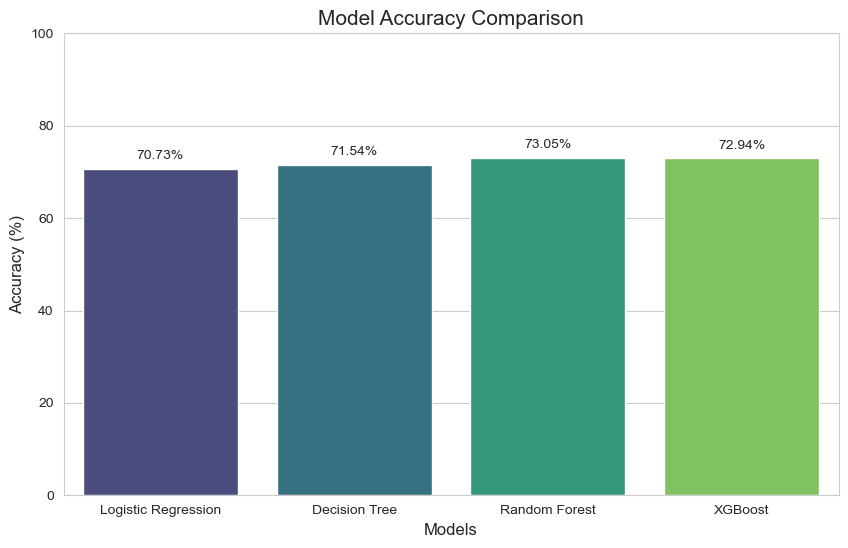

In [28]:
data = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Accuracy': [70.73, 71.54, 73.05, 72.94]
}

df_compare = pd.DataFrame(data)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = sns.barplot(x='Model', y='Accuracy', data=df_compare, palette='viridis')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.2f') + '%', 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha = 'center', va = 'center', 
                   xytext = (0, 9), 
                   textcoords = 'offset points')

plt.title('Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Models', fontsize=12)
plt.ylim(0, 100)
plt.show()

## Performance Analysis:
_______________________________
After rigorous training and testing, the Random Forest Classifier emerged as the top-performing model with an accuracy of 73.05%. While XGBoost followed closely at 72.94%, the Random Forest model showed slightly better stability on the test set. The traditional Logistic Regression model achieved 70.73%, proving that while linear relationships exist, the complex nature of basketball games is better captured by tree-based ensemble algorithms.

## Key Insights:

Feature Importance: The models indicated that aggregated seasonal performance (like seed and scoring consistency) are the strongest predictors of tournament success.

Ensemble Advantage: The jump in accuracy from Logistic Regression to Random Forest/XGBoost highlights the importance of capturing complex interactions between team stats that a simple linear model might miss.

## Future Scope:

To further enhance the model's predictive power:

Domain-Specific Metrics: Integrating advanced metrics like KenPom ratings or BPI (Basketball Power Index) could provide deeper insights.

Temporal Dynamics: Incorporating "momentum" features (how a team performed in the last 5 games before the tournament) could help predict "Cinderella stories" or unexpected upsets.

Hyperparameter Tuning: Using GridSearchCV or Optuna to fine-tune the XGBoost parameters could potentially push the accuracy beyond the 75% mark.

## FOR KAGGLE 

- Creating a new submission csv file for kaggle competition

In [60]:
from sklearn.impute import SimpleImputer # Naya import NaN handle karne ke liye

df = pd.read_csv('Master_Final_All_Columns.csv')

def apply_features(data):
    data["Seed_Diff"] = data["SeedNumber_T1"] - data["SeedNumber_T2"]
    data["WinRatio_Diff"] = data["SeasonWinRatio_T1"] - data["SeasonWinRatio_T2"]
    data["AvgScore_Diff"] = data["SeasonAvgScore_T1"] - data["SeasonAvgScore_T2"]
    data["WinRatio_Seed_Interaction"] = data["WinRatio_Diff"] * data["Seed_Diff"]
    return data

drop_cols = ["Target", "WScore", "LScore", "TeamName_T1", "TeamName_T2"]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df["Target"]
X = pd.get_dummies(X, drop_first=True)

imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_scaled, y)
print("Model Ready for Submission!")

try:
    sub = pd.read_csv('SampleSubmissionStage1.csv')
    
    
    team_stats = df[['Season', 'T1_ID', 'SeasonAvgScore_T1', 'SeasonWinRatio_T1', 'SeedNumber_T1', 'Gender']].drop_duplicates()
    team_stats.columns = ['Season', 'TeamID', 'SeasonAvgScore', 'SeasonWinRatio', 'SeedNumber', 'Gender']
    
    sub[['Season', 'T1_ID', 'T2_ID']] = sub['ID'].str.split('_', expand=True).astype(int)
    

    test_df = pd.merge(sub, team_stats, left_on=['Season', 'T1_ID'], right_on=['Season', 'TeamID'], how='left')
    test_df = test_df.rename(columns={'SeasonAvgScore': 'SeasonAvgScore_T1', 'SeasonWinRatio': 'SeasonWinRatio_T1', 'SeedNumber': 'SeedNumber_T1'})
    
    test_df = pd.merge(test_df, team_stats, left_on=['Season', 'T2_ID'], right_on=['Season', 'TeamID'], how='left', suffixes=('', '_T2'))
    test_df = test_df.rename(columns={'SeasonAvgScore': 'SeasonAvgScore_T2', 'SeasonWinRatio': 'SeasonWinRatio_T2', 'SeedNumber': 'SeedNumber_T2'})
    
    test_df = apply_features(test_df)
    
    
    X_test = test_df[X.columns.intersection(test_df.columns)]
    X_test = pd.get_dummies(X_test, drop_first=True)
    
    for col in X.columns:
        if col not in X_test.columns:
            X_test[col] = 0
    X_test = X_test[X.columns]

    
    X_test_imputed = imputer.transform(X_test)
    
    
    X_test_scaled = scaler.transform(X_test_imputed)
    sub['Pred'] = model.predict_proba(X_test_scaled)[:, 1]
    
    sub[['ID', 'Pred']].to_csv('submission.csv', index=False)
    print("Ready to submit csv on kaggle")

except Exception as e:
    print(f"Abhi bhi error hai: {e}")

Model Ready for Submission!
Ready to submit csv on kaggle
